Resumo: 
Pegamos um arquivo bruto no formato csv retirado de um sistema próprio de um banco. 

1) Primeiro, vemos a "cara" desse arquivo e o que ele define em cada coluna. Depois, nomeamos cada uma das colunas de acordo para facilitar a organização.
2) Começamos a analisar cada uma das colunas, começando pelos dados categóricos (escritos). Usando as funções 'groupby' e 'plot', tentamos encontrar outliers e outros erros aparentes nesses dados.
3) Começamos a analisar os dados numéricos e, usando a função 'describe' e as funções do seaborn 'boxplot' e 'histplot' (histograma), tentamos encontrar outliers e outros erros aparentes nesses dados.

Acaba sendo um processo bem robótico, mas necessário para refinar os dados e posteriormente consertá-los. 

Importando todas as bibliotecas que iremos ultilizar:

In [33]:
import pandas as pd  # usado para manipular o dataframe. 
import numpy as np
import statistics as sts  # usaremos o desvio padrão para detectar outliers. 
import seaborn as seaborn # usaremos esse aqui para fazer gráficos. 

# tudo que vamos precisar para começar a brincar. 

Importando nossa tabela de dados brutos e analisando a cara dela com o head:

In [4]:
# importando os dados:
tabela = pd.read_csv('Churn.csv',sep=';')
# analisando as primeiras 6 linhas
tabela.head()

## conclusão: ainda não entendi nadaa desse dataset. 

,X0,X1,X2,X3,X4,X4.1,X6,X7,X8,X9,X10,X11
0,1,619,RS,Feminino,42,2,0,1,1,1,10134888.0,1
1,2,608,SC,Feminino,41,1,8380786,1,0,1,11254258.0,0
2,3,502,RS,Feminino,42,8,1596608,3,1,0,11393157.0,1
3,4,699,RS,Feminino,39,1,0,2,0,0,9382663.0,0
4,5,850,SC,Feminino,43,2,12551082,1,1,1,790841.0,0


Conhecendo o tamanho do dataframe:

In [10]:
tabela.shape

### fuck. 999 linhas e 12 colunas. 

(999, 12)

Renomeando as colunas:

In [6]:
tabela.columns = ['Id','Score','Estado','Gênero','Idade','Patrimônio','Saldo','Produtos_Adquiridos','TemCartCred','Ativo','Salário','Saiu']
tabela.head()

# Já ficou bem melhor. 

,Id,Score,Estado,Gênero,Idade,Patrimônio,Saldo,Produtos_Adquiridos,TemCartCred,Ativo,Salário,Saiu
0,1,619,RS,Feminino,42,2,0,1,1,1,10134888.0,1
1,2,608,SC,Feminino,41,1,8380786,1,0,1,11254258.0,0
2,3,502,RS,Feminino,42,8,1596608,3,1,0,11393157.0,1
3,4,699,RS,Feminino,39,1,0,2,0,0,9382663.0,0
4,5,850,SC,Feminino,43,2,12551082,1,1,1,790841.0,0


Procurando por erros nos dados categóricos (escritos)
Começando com "Estados":

In [7]:
grupo_estados = tabela.groupby(['Estado']).size()
grupo_estados

# essa fórmula agrupa os dados da coluna "Estado" pelo tamanho.

## Encontramos erros de digitação que formaram nomes de Estados que não existem. 
## No caso desse problema, 'SP' também é um problema, porque o banco só aceita
## clientes do Sul do país. 

Estado
PR    257
RP      1
RS    478
SC    258
SP      4
TD      1
dtype: int64

Plotando um gráfico de barras para analisar esses dados: 

<Axes: xlabel='Estado'>

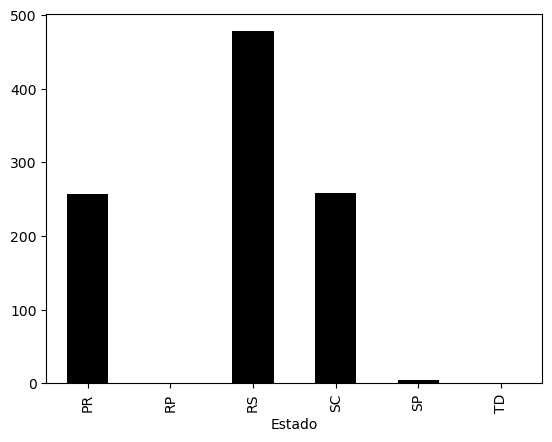

In [14]:
grupo_estados.plot.bar(color = 'black')

## fórmula para plotar um gráfico de barras da cor preta representando os 
## dados de "grupo_estados". 

Procurando por erros em "Gênero":

In [16]:
grupos_genero = tabela.groupby(['Gênero']).size()
print(grupos_genero)

## observe que há problemas em relação a leitura de 'Feminino', 'Fem' e 'F' como 
## coisas diferentes. 

Gênero
F              2
Fem            1
Feminino     461
M              6
Masculino    521
dtype: int64


Gerando um gráfico para analisar os últimos dados:

<Axes: xlabel='Gênero'>

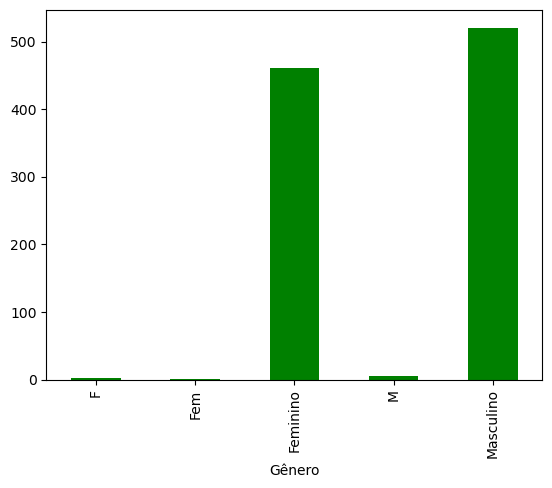

In [20]:
grupos_genero.plot.bar(color = 'green')

Agora, analisando os dados numéricos. 
Começanco pelo "Score": 

In [24]:
tabela['Score'].describe()

# função describe dá um resumo estatístico da coluna escolhida. 

## std = desvio padrão e 50% = mediana. 
## a média e a mediana são bem parecidas, e isso é um indicativo que não tem 
## fortes outliers. 
## não parece haver problemas aqui. 

count    999.000000
mean     648.621622
std       98.264219
min      376.000000
25%      580.000000
50%      653.000000
75%      721.000000
max      850.000000
Name: Score, dtype: float64

Plotando um gráfico 'Boxplot' para analisar esses dados:

<Axes: ylabel='Score'>

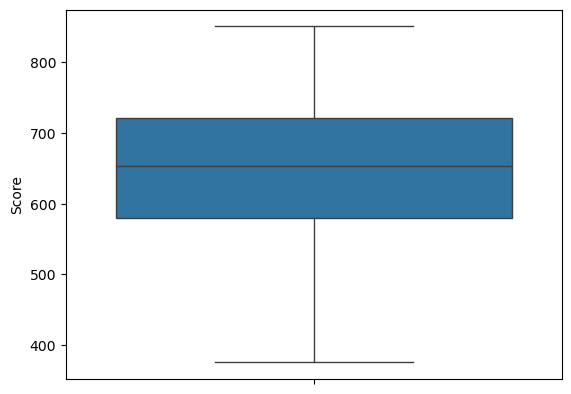

In [34]:
seaborn.boxplot(tabela['Score'])

# dentro da biblioteca 'seaborn', usei a fórmula 'boxplot'. 
# o gráfico mostra a amplitude dos valores, o ponto de 25%, 50% e 75%. 

Plotando um gráfico 'Histograma' para analisar esses dados:

<Axes: xlabel='Score', ylabel='Count'>

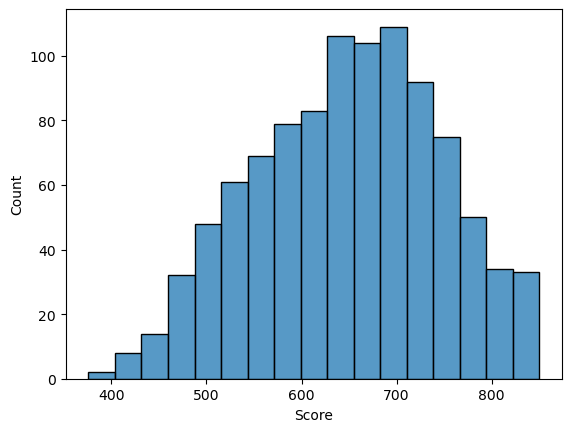

In [35]:
seaborn.histplot(tabela['Score'])

## o histograma me revela a quantidade de clientes por score. 

Analisando agora a coluna de "IDADES". 

In [32]:
tabela['Idade'].describe()

## alguns problemas aparentes: idade mínima negativa e idade máxima muito alta.
## a média e mediana parecidas indicam que esses erros são casos específicos, e 
## nem todos os dados estão corrompidos. 

count    999.000000
mean      38.902903
std       11.401912
min      -20.000000
25%       32.000000
50%       37.000000
75%       44.000000
max      140.000000
Name: Idade, dtype: float64

Boxplot de "Idades": 

<Axes: ylabel='Idade'>

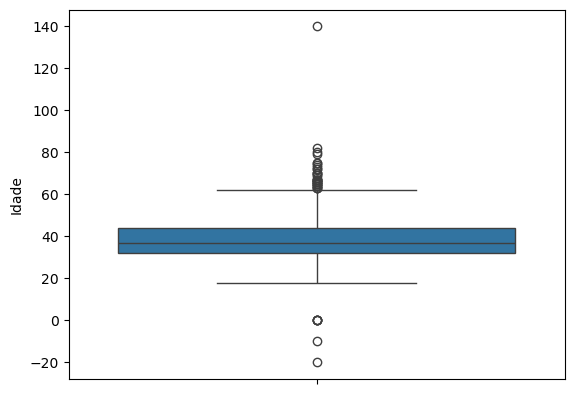

In [37]:
seaborn.boxplot(tabela['Idade'])

Histograma de "Idades": 

<Axes: xlabel='Idade', ylabel='Count'>

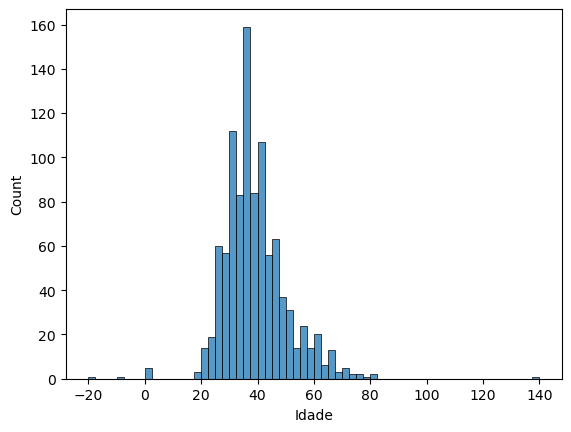

In [38]:
seaborn.histplot(tabela['Idade'])

# o Boxplot e o Histograma acusam haver outliers, valores que provavelmente não
# fazem parte da amplitude estudada, mas ainda estão aqui enchendo o saco. 

In [39]:
tabela.groupby('Idade').size()

# o professor não faz isso, mas decidi usar o groupby para analisar exatamente 
# quantos outliers temos nesses dados. Provavelmente os substituíremos pela 
# mediana. 

Idade
-20     1
-10     1
 0      5
 18     1
 19     2
       ..
 75     2
 79     1
 80     1
 82     1
 140    1
Length: 64, dtype: int64

SALDO: 

In [40]:
tabela['Saldo'].describe()

# os dados são meio esquisitos por causa da criptografia. não vejo nada de muito 
# errado pela descrição. 

count    9.990000e+02
mean     7.164928e+06
std      6.311840e+06
min      0.000000e+00
25%      0.000000e+00
50%      8.958835e+06
75%      1.258684e+07
max      2.117743e+07
Name: Saldo, dtype: float64

<Axes: ylabel='Saldo'>

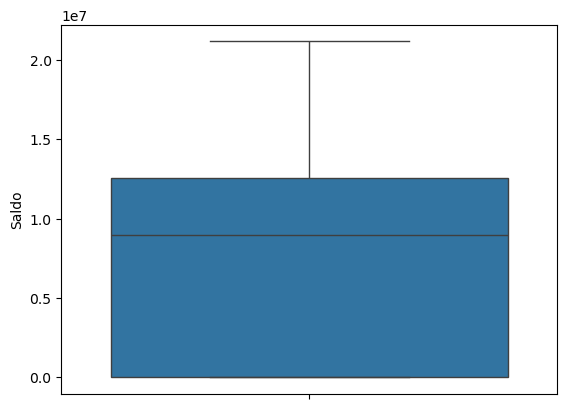

In [42]:
seaborn.boxplot(tabela['Saldo'])

# aparentemente, existe uma concentração de individuos que não tem saldo no banco
# ou saldo = 0 sendo analisados. 

<Axes: xlabel='Saldo', ylabel='Count'>

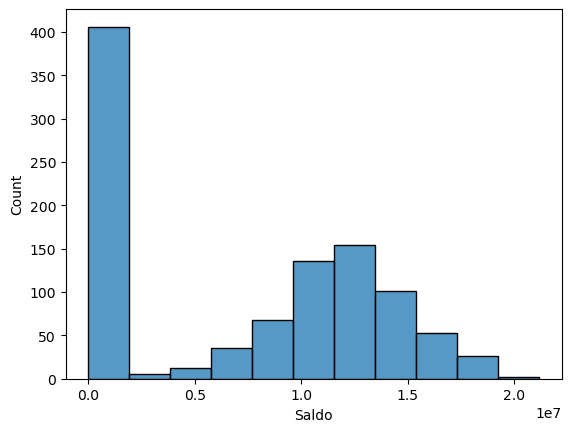

In [41]:
seaborn.histplot(tabela['Saldo'])

# o histograma mostra a última observação muito bem. Mas nenhum erro até então.

SALÁRIO: 

In [43]:
tabela['Salário'].describe()

# não vejo nenhum erro até então. 

count    9.920000e+02
mean     3.528762e+07
std      5.305800e+08
min      9.677000e+03
25%      3.029011e+06
50%      8.703250e+06
75%      1.405213e+07
max      1.193469e+10
Name: Salário, dtype: float64

<Axes: ylabel='Salário'>

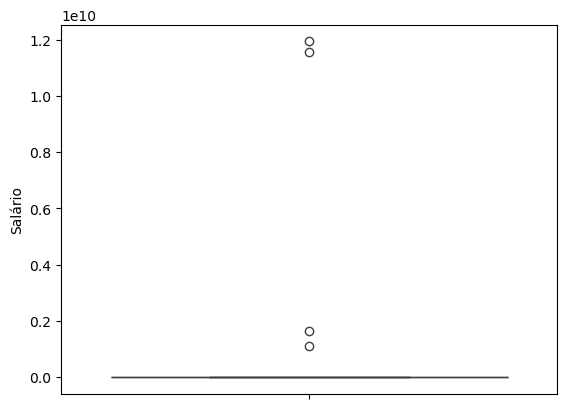

In [44]:
seaborn.boxplot(tabela['Salário'])

# isso ficou esquisito. muita concentração no zero. 

<Axes: xlabel='Salário', ylabel='Count'>

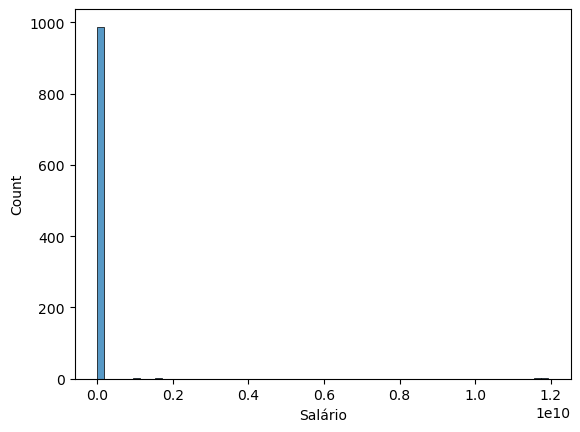

In [45]:
seaborn.histplot(tabela['Salário'])

# agora dá pra ver que a concentração no zero é bem maior. isso se deve ao fato
# de que a maioria dos clientes não informou o valor do salário. 

Contando o número de dados VAZIOS ou NAN: 

In [48]:
tabela.isnull().sum()

# Aparecem dados vazios no gênero e no salário. Precisaremos tratar isso. 

Id                     0
Score                  0
Estado                 0
Gênero                 8
Idade                  0
Patrimônio             0
Saldo                  0
Produtos_Adquiridos    0
TemCartCred            0
Ativo                  0
Salário                7
Saiu                   0
dtype: int64